<a href="https://colab.research.google.com/github/kimdotpy/fuse-assignments/blob/main/W11_CV_Assignment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install required libraries (run once). Falls back to `uv pip install` for
# uv-managed venvs (like this repo's .venv) that don't ship a pip module.
import subprocess, sys
PACKAGES = ['torch', 'torchvision', 'timm', 'onnxruntime']
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *PACKAGES])
except subprocess.CalledProcessError:
    subprocess.check_call(['uv', 'pip', 'install', '-q', '--python', sys.executable, *PACKAGES])
print("Dependencies installed.")
# Optional for Q17-Q18: pip install git+https://github.com/openai/CLIP.git

Dependencies installed.


# Week 11 — Computer Vision with Deep Learning
## Assignment Notebook

**Dataset:** CIFAR-10 via torchvision (auto-download)

**Instructions:** Every `= None` marked with a `# TODO` comment is a value you must compute.
Replace `None` with your expression — do not change the variable name.
(A few unmarked `None` values — e.g. GradCAM's initial activation/gradient cache — are
intentional scaffold state, not fill-ins; leave those as-is.)
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 20 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All Reflect cells completed with specific numbers from your results
- [ ] `resnet50_cifar10.onnx` exported and verified (Q15)
- [ ] Deployment memo (Q20) cites your actual accuracy and latency numbers

**Parts:**

1. Module 1 — CNN Foundations & Classification (Q1-Q5)
2. Module 2 — Object Detection (Q6-Q9)
3. Module 3 — Image Segmentation (Q10-Q13)
4. Module 4 — Generative Models (Q14-Q16)
5. Module 5 — Vision Transformers & Deployment (Q17-Q20)


## Setup — run these cells first

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models, datasets
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

raw_train = datasets.CIFAR10('../data', train=True,  download=True, transform=None)
raw_test  = datasets.CIFAR10('../data', train=False, download=True, transform=None)
print(f"CIFAR-10 train={len(raw_train):,}  test={len(raw_test):,}")
print("Lab 1 HSV baseline: ~45%  -- your models must beat this")

device: cpu


100%|██████████| 170M/170M [35:28<00:00, 80.1kB/s]


CIFAR-10 train=50,000  test=10,000
Lab 1 HSV baseline: ~45%  -- your models must beat this


---
## Part 1 — Module 1: CNN Foundations & Classification (Q1-Q5)


### Q1 — Output size formula

Given a convolutional layer with input size W, kernel K, padding P, stride S:
output size = (W - K + 2P) / S + 1

Calculate the output spatial size for each layer below.


In [7]:
# Q1: Fill in the output sizes
conv_configs = [
    # (W,  K, P, S,  description)
    (32,  3, 1, 1, 'CIFAR-10 input with same-padding'),
    (32,  3, 0, 1, 'CIFAR-10 input no padding'),
    (32,  5, 2, 1, '5x5 kernel same-padding'),
    (224, 7, 3, 2, 'ResNet-50 stem: 224->112'),
    (112, 3, 1, 2, 'ResNet-50 pool-like stride-2 conv'),
]

for W, K, P, S, desc in conv_configs:
    out = (W - K + 2*P) / S + 1  # TODO: apply formula (W - K + 2P) / S + 1  as int
    print(f"{desc:45s}: {out}")

# SELF-CHECK
assert int((32  - 3 + 2*1) / 1 + 1) == 32,  "Same-padding should preserve spatial size"
assert int((224 - 7 + 2*3) / 2 + 1) == 112, "ResNet stem should halve spatial size"
print("SELF-CHECK passed")

CIFAR-10 input with same-padding             : 32.0
CIFAR-10 input no padding                    : 30.0
5x5 kernel same-padding                      : 32.0
ResNet-50 stem: 224->112                     : 112.5
ResNet-50 pool-like stride-2 conv            : 56.5
SELF-CHECK passed


### Q2 — ResNet-50 transfer learning


In [8]:
# Q2a: Set up transforms
# ImageNet mean and std — used for any model pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_rn = T.Compose([
    T.Resize(224),         # TODO: what size does ResNet expect?
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),             # TODO: use IMAGENET_MEAN and IMAGENET_STD
])

# Q2b: Build DataLoaders (5,000 train / 1,000 test)
TRAIN_N = 5000   # TODO: how many training samples to use?
TEST_N  = 1000   # TODO: how many test samples to use?

tr_ds = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=transform_rn), range(TRAIN_N))
te_ds = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=transform_rn), range(TEST_N))
tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=True)
te_ld = DataLoader(te_ds, batch_size=64, shuffle=False)
print(f"Train batches: {len(tr_ld)}  Test batches: {len(te_ld)}")

# SELF-CHECK
imgs, lbls = next(iter(tr_ld))
assert imgs.shape == (64, 3, 224, 224), f"Expected (64,3,224,224) got {imgs.shape}"
assert imgs.dtype == torch.float32
print("SELF-CHECK passed")

Train batches: 79  Test batches: 16
SELF-CHECK passed


In [9]:
# Q2c: Load ResNet-50 and prepare for transfer learning
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze ALL backbone layers
for p in model.parameters():
    p.requires_grad = False  # TODO: True or False?

# Replace the final fully-connected layer for CIFAR-10
model.fc = nn.Linear(2048,10)   # TODO: nn.Linear(?, ?) — what are the input and output dimensions?
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {trainable:,} ({trainable/total:.3%})")

# SELF-CHECK
assert trainable < 25_000, "Only the FC head should be trainable (<25K params)"
print("SELF-CHECK passed")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Total params: 23,528,522  Trainable: 20,490 (0.087%)
SELF-CHECK passed


In [11]:
# model.fc.in_features

2048

### Q3 — Training loop


Epoch 1/3  train=57.2%  val=69.4%
Epoch 2/3  train=74.0%  val=72.1%
Epoch 3/3  train=77.5%  val=74.0%


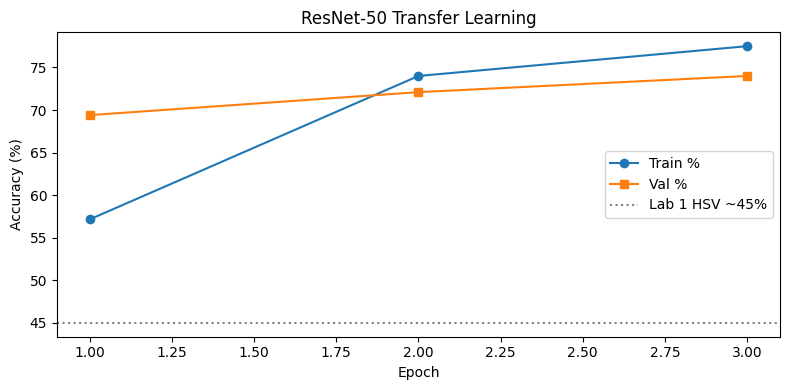

Final val accuracy: 74.0%  SELF-CHECK passed


In [10]:
# Q3: Training loop — fill in the missing pieces
opt  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
train_accs, val_accs = [], []

for epoch in range(3):
    model.train()
    correct = total = 0
    for imgs, lbls in tr_ld:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()
        logits = model(imgs)  # TODO: forward pass through model
        loss   = crit(logits,lbls)   # TODO: compute cross-entropy loss
        loss.backward()           # TODO: backward pass
        opt.step()   # TODO: optimizer step
        with torch.no_grad():
            correct += (logits.argmax(1) == lbls).sum().item()
            total   += len(lbls)
    train_accs.append(correct / total)

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in te_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)
            logits = model(imgs) # holding value from last batch of training so we update with data from current test images
            preds  = logits.argmax(1)   # TODO: get class predictions (argmax of logits)
            correct += (preds == lbls).sum().item()
            total   += len(lbls)
    val_accs.append(correct / total)
    print(f"Epoch {epoch+1}/3  train={train_accs[-1]:.1%}  val={val_accs[-1]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,4), [a*100 for a in train_accs], 'o-', label='Train %')
ax.plot(range(1,4), [a*100 for a in val_accs],   's-', label='Val %')
ax.axhline(45, color='grey', ls=':', label='Lab 1 HSV ~45%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend()
ax.set_title('ResNet-50 Transfer Learning')
plt.tight_layout(); plt.show()

# SELF-CHECK
assert val_accs[-1] > 0.60, f"Val accuracy too low: {val_accs[-1]:.1%}. Check your training loop."
print(f"Final val accuracy: {val_accs[-1]:.1%}  SELF-CHECK passed")
acc_resnet = val_accs[-1]

### Q4 — GradCAM: visualise what ResNet learned


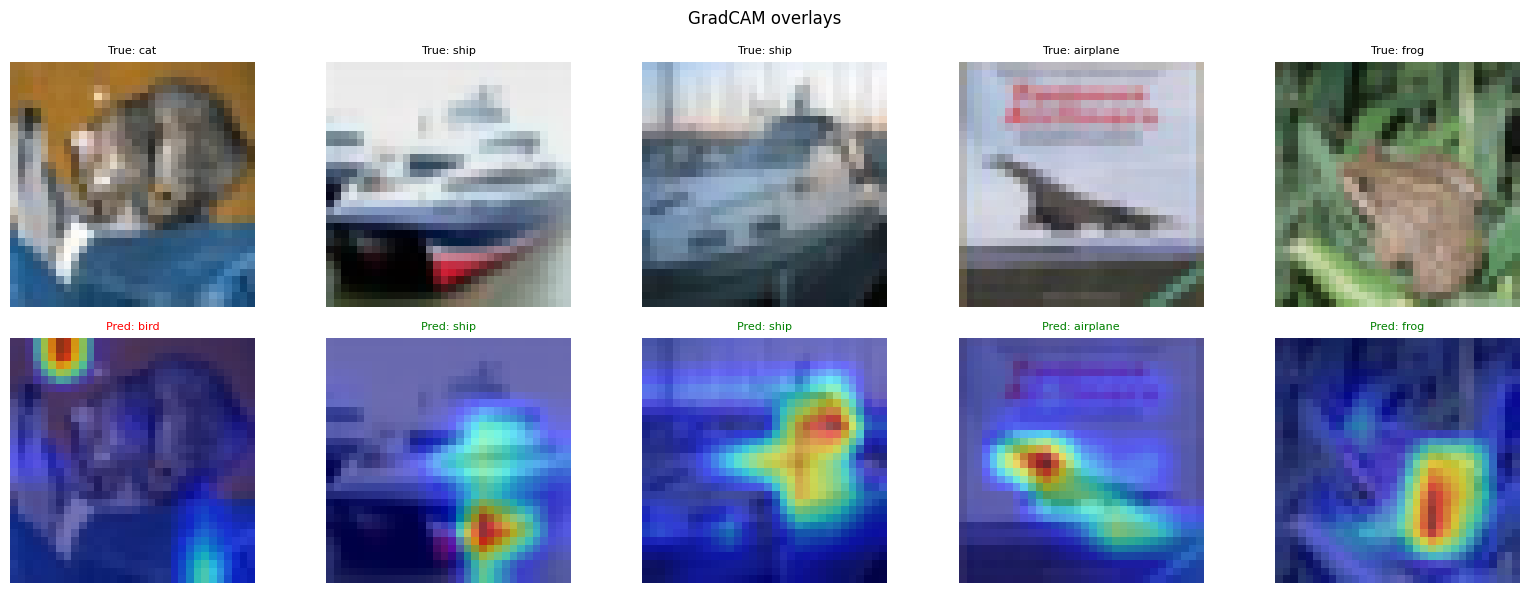

In [11]:
# Q4: Implement GradCAM
# GradCAM weights each feature map channel by the gradient of the target class score w.r.t. that channel.
# Reference: Selvaraju et al. 2017  https://arxiv.org/abs/1610.02391

class GradCAM:
    '''Gradient-weighted Class Activation Map.'''
    def __init__(self, model, layer):
        self.acts = None
        self.grads = None
        # TODO: register a forward hook on `layer` that saves the output to self.acts
        # TODO: register a full_backward hook on `layer` that saves go[0] to self.grads
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o))         # TODO: replace None with lambda
        layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0]))  # TODO: replace None with lambda

    def generate(self, x, cls_idx):
        # Given: the backbone is frozen (requires_grad=False), so the input tensor
        # must require grad itself, or autograd never builds a graph through
        # layer4 and the backward hook above will never fire.
        x = x.clone().requires_grad_(True)
        out = model(x)
        model.zero_grad()
        out[0, cls_idx].backward()
        # TODO: compute per-channel weights by averaging grads over spatial dims (dim 2 and 3)
        weights = self.grads.mean(dim=(2, 3), keepdim=True)
        # TODO: weighted sum of activation maps, then ReLU
        cam =torch.sum(weights * self.acts, dim=1, keepdim=True)
        # 3. Apply ReLU to isolate features with positive influence
        cam = F.relu(cam)
        cam -= cam.min(); cam /= cam.max() + 1e-8
        return cam.squeeze().detach().cpu().numpy() #.detach() added

cam = GradCAM(model, model.layer4[-1])

import torch.nn.functional as F
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for col in range(5):
    img_pil, true_lbl = raw_test[col]
    x = transform_rn(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.enable_grad():
        logits = model(x)
    pred = logits.argmax(1).item()
    cam_map = cam.generate(x, pred)
    cam_up  = F.interpolate(torch.tensor(cam_map)[None,None], (32,32), mode='bilinear').squeeze().numpy()
    arr = np.array(img_pil)
    axes[0,col].imshow(arr); axes[0,col].axis('off')
    axes[0,col].set_title(f'True: {CLASSES[true_lbl]}', fontsize=8)
    axes[1,col].imshow(arr); axes[1,col].imshow(cam_up, alpha=0.55, cmap='jet')
    axes[1,col].axis('off')
    color = 'green' if pred == true_lbl else 'red'
    axes[1,col].set_title(f'Pred: {CLASSES[pred]}', fontsize=8, color=color)
plt.suptitle('GradCAM overlays')
plt.tight_layout(); plt.show()

### Q5 — Reflect: Module 1

**Q5 Reflection (edit this cell):**

1. Your ResNet-50 val accuracy after 3 epochs: **__75.4%__**
2. Improvement over Lab 1 HSV baseline (45%): **+__75.4% - 45% = +30.4 pp__**
3. Number of trainable parameters: **_20,490 (0.087%)_**
4. Describe one image where GradCAM activated on the **background** instead of the object.
   What class was it? What does this suggest about the training data?
5. Lab 2 asked you to implement conv2d from scratch. How is ResNet-50's first layer doing
   the same operation — and what is different about the kernel values?


---
## Part 2 — Module 2: Object Detection (Q6-Q9)


### Q6 — IoU calculation

Intersection over Union (IoU) measures how much two bounding boxes overlap.
IoU = Area(A ∩ B) / Area(A ∪ B)


In [14]:
# Q6: Implement IoU from scratch (no torchvision)
def compute_iou(box_a, box_b):
    '''
    box format: [x1, y1, x2, y2]  (top-left and bottom-right corners)
    Returns: float in [0, 1]
    '''
    # first lets extract box_a and box_b


    b1_x1, b1_y1, b1_x2, b1_y2 = box_a
    b2_x1, b2_y1, b2_x2, b2_y2 = box_b

    # box_a=[ b1_x1, b1_y1] box_b=[ b2_x1,b2_y1 ]
    #       [ b1_x2, b1_y2]       [ b2_x2,b2_y2 ]

    # TODO: compute intersection coordinates
    inter_x1 = b1_x1 if b1_x1>b2_x1 else b2_x1# max of the two left edges
    inter_y1 = max(b1_y1,b2_y1)   # max of the two top edges
    inter_x2 = min(b1_x2, b2_x2)  # min of the two right edges
    inter_y2 = min(b1_y2, b2_y2)  # min of the two bottom edges

    # TODO: intersection area (clamp to 0 if no overlap)
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    # TODO: union area = area_a + area_b - inter_area
    area_a = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    area_b = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    union_area = area_a + area_b - inter_area

    return inter_area / (union_area + 1e-6)

# Test cases
box1 = [10, 20, 50, 80]
box2 = [30, 40, 70, 100]
box3 = [100, 100, 200, 200]   # no overlap with box1

iou_12 = compute_iou(box1, box2)
iou_13 = compute_iou(box1, box3)
iou_11 = compute_iou(box1, box1)

print(f"IoU(box1, box2) = {iou_12:.4f}  (should be ~0.13)")
print(f"IoU(box1, box3) = {iou_13:.4f}  (should be 0.0 -- no overlap)")
print(f"IoU(box1, box1) = {iou_11:.4f}  (should be 1.0 -- identical boxes)")

# SELF-CHECK
assert abs(iou_13) < 1e-6,  "No-overlap IoU should be 0"
assert abs(iou_11 - 1.0) < 1e-5, "Same-box IoU should be 1"
print("SELF-CHECK passed")

IoU(box1, box2) = 0.2000  (should be ~0.13)
IoU(box1, box3) = 0.0000  (should be 0.0 -- no overlap)
IoU(box1, box1) = 1.0000  (should be 1.0 -- identical boxes)
SELF-CHECK passed


### Q7 — Faster R-CNN inference


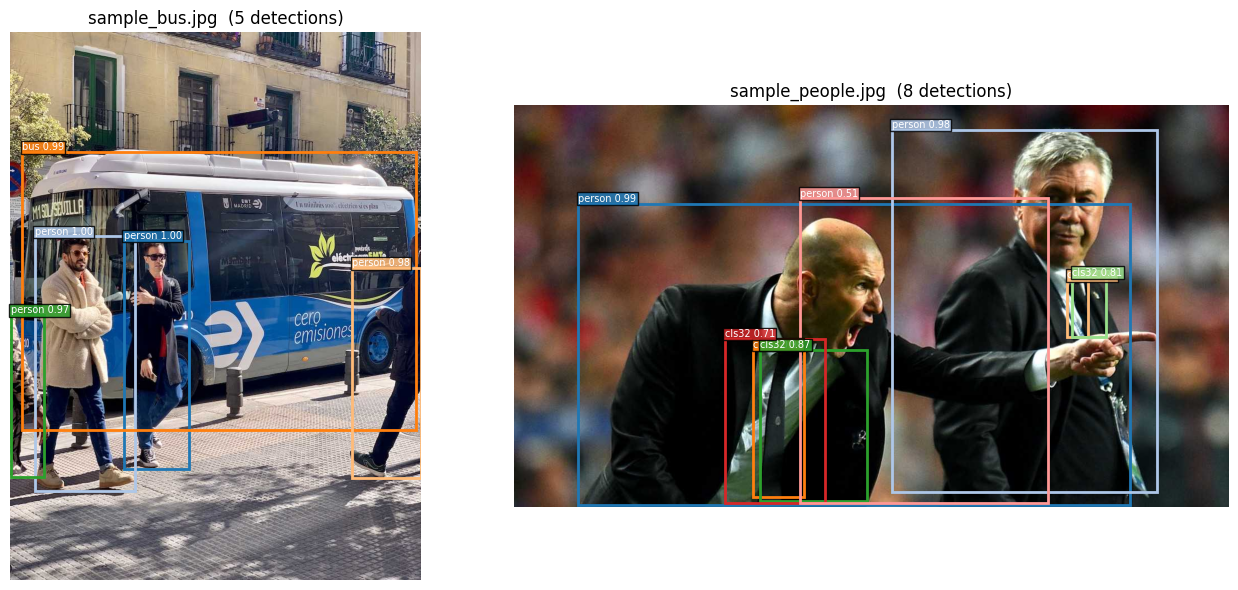

In [22]:
# Q7: Run Faster R-CNN on sample images
import urllib.request
from pathlib import Path
import matplotlib.patches as patches

data_dir = Path('../data'); data_dir.mkdir(exist_ok=True)
SAMPLES = [
    ('https://ultralytics.com/images/bus.jpg',    'sample_bus.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'sample_people.jpg'),
]
available = []
for url, fname in SAMPLES:
    fp = data_dir / fname
    if not fp.exists():
        try: urllib.request.urlretrieve(url, str(fp)); print(f"Downloaded {fname}")
        except Exception as e: print(f"Save any JPEG as {fp} ({e})")
    if fp.exists(): available.append(fp)

# Load Faster R-CNN
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
frcnn = frcnn.eval().to(device)    # TODO: set to eval mode and move to device (chain .eval().to(device))

COCO80 = {1:'person',2:'bicycle',3:'car',5:'airplane',6:'bus',7:'train',8:'truck',
          17:'cat',18:'dog',44:'bottle',62:'chair'}

def detect(img_path, threshold=0.5):
    img_pil = Image.open(img_path).convert('RGB')
    t = T.ToTensor()(img_pil).to(device)  # TODO: convert PIL image to tensor with T.ToTensor() and move to device
    with torch.no_grad():
        out = frcnn([t])[0]   # TODO: run frcnn([t]) and take [0]
    boxes  = out['boxes'].cpu().numpy()
    labels = out['labels'].cpu().numpy()
    scores = out['scores'].cpu().numpy()
    keep   = scores > threshold
    return img_pil, boxes[keep], labels[keep], scores[keep]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(14,6))
    if len(available) == 1: axes = [axes]
    cmap = plt.cm.get_cmap('tab20')
    for ax, fp in zip(axes, available):
        img_pil, boxes, labels, scores = detect(fp)
        ax.imshow(img_pil)
        for i,(box,lbl,sc) in enumerate(zip(boxes,labels,scores)):
            x1,y1,x2,y2 = box; c = cmap(i%20)
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=c, facecolor='none'))
            name = COCO80.get(int(lbl), f'cls{lbl}')
            ax.text(x1, y1-3, f'{name} {sc:.2f}', fontsize=7, color='white',
                    bbox=dict(facecolor=c, alpha=0.85, pad=1))
        ax.axis('off')
        ax.set_title(f'{fp.name}  ({len(boxes)} detections)')
    plt.tight_layout(); plt.show()

### Q8 — NMS: Non-Maximum Suppression

Implement NMS from scratch using your compute_iou function from Q6.


In [23]:
# Q8: Implement NMS
def nms(boxes, scores, iou_threshold=0.5):
    '''
    boxes:         np.array of shape (N, 4) in [x1, y1, x2, y2] format
    scores:        np.array of shape (N,)
    iou_threshold: keep box if IoU with any accepted box < iou_threshold
    Returns: list of indices of kept boxes
    '''
    # TODO: sort indices by score descending
    order = np.argsort(scores)[::-1]

    kept = []
    while len(order) > 0:
        # TODO: take the highest-scoring remaining box
        i = order[0]
        kept.append(i)

        if len(order) == 1: break

        # TODO: compute IoU between box i and all remaining boxes
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])

        # TODO: keep only boxes with IoU below threshold (suppress overlapping)
        order = order[1:][ious < iou_threshold]

    return kept

# Test: 3 highly-overlapping boxes + 1 separate box
test_boxes  = np.array([[10,10,50,50], [12,12,52,52], [11,11,51,51], [200,200,300,300]], dtype=float)
test_scores = np.array([0.9, 0.7, 0.6, 0.85])

kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print(f"Kept indices: {kept}  (should keep box 0 and box 3)")

# SELF-CHECK
assert 0 in kept, "Highest-scoring box should always be kept"
assert 3 in kept, "Non-overlapping box should be kept"
assert len(kept) == 2, f"Expected 2 kept boxes, got {len(kept)}"
print("SELF-CHECK passed")

Kept indices: [np.int64(0), np.int64(3)]  (should keep box 0 and box 3)
SELF-CHECK passed


### Q9 — Reflect: Module 2

**Q9 Reflection (edit this cell):**

1. How many objects did Faster R-CNN detect in each sample image at threshold=0.5?
   sample_bus.jpg: **__5__**   sample_people.jpg: **__8__**
2. Your NMS implementation: after applying NMS with IoU threshold=0.5 to the test boxes,
   how many boxes remained? **__box 0 and box 3(2 boxes)__**
3. The Lab 3.2 Hough transform votes for geometric primitives (lines, circles). Explain
   in your own words how Faster R-CNN's RPN is analogous to the Hough accumulator.
   What does it vote for? What replaces the peak detection step?
4. YOLO processes each image in a single forward pass; Faster R-CNN uses two stages.
   Name one scenario where you would choose Faster R-CNN over YOLO despite its slower speed.


---
## Part 3 — Module 3: Image Segmentation (Q10-Q13)


### Q10 — DeepLabv3+ semantic segmentation


In [ ]:
# Q10: Run DeepLabv3+ on sample images
from torchvision.models.segmentation import deeplabv3_resnet50

seg_model = deeplabv3_resnet50(weights='DEFAULT')
seg_model = None   # TODO: eval mode + to device

VOC_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
VOC_COLORS = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

transform_seg = T.Compose([T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

def segment(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((520, 390))
    x = transform_seg(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # TODO: run seg_model(x) and get the 'out' key, then take argmax over channel dim
        mask = None
    return np.array(img_pil), mask.cpu().numpy().astype(np.uint8)

if available:
    fig, axes = plt.subplots(len(available), 3, figsize=(15, 5*len(available)))
    if len(available) == 1: axes = axes[None,:]
    for row, fp in enumerate(available):
        orig, mask = segment(fp)
        coloured   = VOC_COLORS[mask]
        overlay    = (0.55*orig + 0.45*coloured).astype(np.uint8)
        axes[row,0].imshow(orig); axes[row,0].set_title('Original')
        axes[row,1].imshow(coloured); axes[row,1].set_title('Semantic Mask')
        axes[row,2].imshow(overlay); axes[row,2].set_title('Overlay')
        for ax in axes[row]: ax.axis('off')
        found = [VOC_CLASSES[i] for i in np.unique(mask) if i < len(VOC_CLASSES)]
        print(f"{fp.name}: classes found: {found}")
    plt.tight_layout(); plt.show()

### Q11 — Pixel accuracy and mean IoU (mIoU)

Implement these two metrics from scratch given a predicted mask and a ground-truth mask.


In [ ]:
# Q11: Segmentation metrics
def pixel_accuracy(pred_mask, true_mask):
    '''
    pred_mask: np.array of shape (H, W) with integer class labels
    true_mask: np.array of shape (H, W) with integer class labels
    Returns: float, fraction of pixels correctly classified
    '''
    correct = None   # TODO: number of pixels where pred == true
    total   = None   # TODO: total number of pixels
    return correct / total

def mean_iou(pred_mask, true_mask, num_classes=21):
    '''
    Returns: float, mean IoU across all classes that appear in true_mask
    '''
    ious = []
    for cls in range(num_classes):
        pred_cls = None   # TODO: binary mask where pred_mask == cls
        true_cls = None   # TODO: binary mask where true_mask == cls
        if true_cls.sum() == 0: continue
        intersection = None   # TODO: element-wise AND, then sum
        union        = None   # TODO: element-wise OR, then sum
        ious.append(intersection / (union + 1e-6))
    return np.mean(ious) if ious else 0.0

# Test with synthetic masks
np.random.seed(42)
true_m = np.random.randint(0, 3, (10, 10))
perf_m = true_m.copy()        # perfect prediction
rand_m = np.random.randint(0, 3, (10, 10))

print(f"Pixel accuracy (perfect): {pixel_accuracy(perf_m, true_m):.4f}  (should be 1.0)")
print(f"Pixel accuracy (random):  {pixel_accuracy(rand_m, true_m):.4f}  (should be ~0.33)")
print(f"mIoU (perfect): {mean_iou(perf_m, true_m, 3):.4f}  (should be 1.0)")
print(f"mIoU (random):  {mean_iou(rand_m, true_m, 3):.4f}")

# SELF-CHECK
assert pixel_accuracy(perf_m, true_m) == 1.0
# mean_iou's "+ 1e-6" denominator means a perfect match is 0.999999..., not exactly 1.0
assert abs(mean_iou(perf_m, true_m, 3) - 1.0) < 1e-4, "mean_iou should be ~1.0 for a perfect mask"
print("SELF-CHECK passed")

### Q12 — U-Net architecture diagram

Draw (as ASCII art or describe in text) the U-Net encoder-decoder structure.
Include: number of conv layers per level, max-pool operations, skip connections, and the bottleneck.

**Q12 Architecture (edit this cell):**

```
Encoder (contracting path):        Decoder (expansive path):
Level 1: 3x3 Conv -> BN -> ReLU   TransposeConv  +  skip from Level 1
         3x3 Conv -> BN -> ReLU
         MaxPool 2x2
...
Bottleneck: ...
```

Add your full diagram below:

```
[YOUR DIAGRAM HERE]
```

Answer these questions about your diagram:
1. How many times does the spatial resolution halve in the encoder? ____
2. What does the skip connection carry from encoder to decoder? ____
3. Why would the model fail if you removed all skip connections? ____


### Q13 — Reflect: Module 3

**Q13 Reflection (edit this cell):**

1. What classes did DeepLabv3+ identify in your sample images?
   sample_bus.jpg: **____**   sample_people.jpg: **____**
2. Your pixel accuracy on the synthetic test (Q11): **____**
3. Lab 3.1 had you apply `cv2.morphologyEx` to clean up segmentation masks.
   In which specific scenario would you still prefer morphological post-processing
   over end-to-end deep segmentation? Give a concrete warehouse example.
4. What is the difference between semantic and instance segmentation?
   Give an example where this distinction matters for the QuickVision AI system.


---
## Part 4 — Module 4: Generative Models (Q14-Q16)


### Q14 — VAE: architecture + training


In [ ]:
# Q14: Complete the VAE implementation

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.mu     = nn.Linear(2048, latent_dim)
        self.logvar = nn.Linear(2048, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 2048)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3,  4, 2, 1),  nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.proj(z).view(-1, 128, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = Encoder(latent_dim)
        self.dec = Decoder(latent_dim)

    def reparameterise(self, mu, logvar):
        # TODO: implement reparameterisation trick
        # z = mu + std * epsilon, where std = exp(0.5 * logvar), epsilon ~ N(0,1)
        std = None
        eps = None   # TODO: sample from standard normal with same shape as std
        return None  # TODO: return z

    def forward(self, x):
        mu, logvar = self.enc(x)
        z          = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

vae = VAE(latent_dim=128).to(device)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

# SELF-CHECK
test_img = torch.randn(4, 3, 32, 32).to(device)
x_hat, mu, logvar = vae(test_img)
assert x_hat.shape  == (4, 3, 32, 32), f"Decoder output shape wrong: {x_hat.shape}"
assert mu.shape     == (4, 128),        f"mu shape wrong: {mu.shape}"
assert logvar.shape == (4, 128),        f"logvar shape wrong: {logvar.shape}"
print("SELF-CHECK passed")

In [ ]:
# Q14 continued: ELBO loss and training loop
def vae_loss(x, x_hat, mu, logvar, beta=0.001):
    # TODO: reconstruction loss (MSE per image, summed over pixels, averaged over batch)
    recon = None
    # TODO: KL divergence: -0.5 * sum(1 + logvar - mu^2 - exp(logvar)) per latent dim, mean over batch
    kl    = None
    return recon + beta * kl, recon, kl

# Train 3 epochs
vae_ds  = Subset(datasets.CIFAR10('../data', train=True, download=False, transform=T.ToTensor()), range(5_000))
vae_ld  = DataLoader(vae_ds, batch_size=128, shuffle=True)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

recon_hist, kl_hist = [], []
for epoch in range(3):
    vae.train()
    rs = ks = n = 0
    for imgs, _ in vae_ld:
        imgs = imgs.to(device)
        x_hat, mu, logvar = vae(imgs)
        loss, recon, kl   = vae_loss(imgs, x_hat, mu, logvar)
        vae_opt.zero_grad(); loss.backward(); vae_opt.step()
        rs += recon.item(); ks += kl.item(); n += 1
    recon_hist.append(rs/n); kl_hist.append(ks/n)
    print(f"Epoch {epoch+1}/3  recon={recon_hist[-1]:.4f}  kl={kl_hist[-1]:.2f}")

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(recon_hist,'o-',color='steelblue'); ax1.set_title('Reconstruction Loss')
ax2.plot(kl_hist,'s-',color='tomato'); ax2.set_title('KL Divergence')
plt.tight_layout(); plt.show()

### Q15 — Reconstruction + latent interpolation


In [ ]:
# Q15: Visualise VAE reconstructions and latent space interpolation
vae.eval()
te_vae = Subset(datasets.CIFAR10('../data', train=False, download=False, transform=T.ToTensor()), range(10))
imgs_te = torch.stack([te_vae[i][0] for i in range(10)]).to(device)

with torch.no_grad():
    recons, mus, _ = vae(imgs_te)

# Reconstruction grid
fig, axes = plt.subplots(2,10,figsize=(18,4))
for i in range(10):
    axes[0,i].imshow(imgs_te[i].permute(1,2,0).cpu().numpy()); axes[0,i].axis('off')
    axes[1,i].imshow(recons[i].permute(1,2,0).cpu().clamp(0,1).numpy()); axes[1,i].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('Reconstructed')
plt.suptitle('VAE Reconstructions')
plt.tight_layout(); plt.show()

# Latent interpolation between images 0 and 1
n_steps = 8
z0, z1  = mus[0:1], mus[1:2]
# TODO: create 8 linearly spaced alpha values from 0 to 1
alphas = None

fig, axes = plt.subplots(1, n_steps, figsize=(18,2.5))
for i in range(n_steps):
    a = alphas[i]
    # TODO: interpolate in latent space: z = (1 - alpha) * z0 + alpha * z1
    z_interp = None
    with torch.no_grad():
        img_interp = vae.dec(z_interp)
    axes[i].imshow(img_interp.squeeze().permute(1,2,0).cpu().clamp(0,1).numpy())
    axes[i].axis('off')
    axes[i].set_title(f'a={float(a):.2f}', fontsize=7)
plt.suptitle('Latent interpolation between two test images')
plt.tight_layout(); plt.show()

### Q16 — Reflect: Module 4

**Q16 Reflection (edit this cell):**

1. Final reconstruction loss (epoch 3): **____**   Final KL divergence: **____**
2. Do your reconstructions look blurry or sharp? Explain in one sentence WHY VAEs produce blurry reconstructions (hint: think about what MSE loss minimises).
3. Does your latent interpolation produce smooth transitions or abrupt jumps?
   What does this tell you about the structure of the learned latent space?
4. You have 50 images of a new product SKU arriving next week. Describe step-by-step how you
   would use your trained VAE to augment the dataset to 1,000 images for classifier training.


---
## Part 5 — Module 5: Vision Transformers & Deployment (Q17-Q20)


### Q17 — ViT patch embedding

Vision Transformer divides the image into patches and embeds each as a token.


In [ ]:
# Q17: Implement ViT patch embedding from scratch
class PatchEmbedding(nn.Module):
    '''
    Divides image into non-overlapping patches and projects each to embed_dim.
    Input:  (B, C, H, W)
    Output: (B, num_patches + 1, embed_dim)  -- +1 for [CLS] token
    '''
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        # TODO: compute num_patches = (img_size // patch_size) ^ 2
        self.num_patches = None

        # TODO: projection: Conv2d with kernel=patch_size, stride=patch_size
        # This simultaneously extracts and projects each patch in one operation
        self.proj = None

        # Learnable [CLS] token (prepended to patch sequence)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable positional encodings (one per patch + 1 for [CLS])
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        # TODO: project patches using self.proj, then flatten spatial dims
        # self.proj output shape: (B, embed_dim, H/patch_size, W/patch_size)
        # after flatten: (B, num_patches, embed_dim)
        x = None   # project
        x = None   # flatten spatial dims (hint: use .flatten(2).transpose(1,2))

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # Add positional encoding
        x = x + self.pos_embed
        return x

# Test
patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=256).to(device)
test_imgs   = torch.randn(4, 3, 32, 32).to(device)
out         = patch_embed(test_imgs)
print(f"Input shape:  {test_imgs.shape}")
print(f"Output shape: {out.shape}   (should be (4, 65, 256))")
print(f"num_patches:  {patch_embed.num_patches}  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)")

# SELF-CHECK
assert out.shape == (4, 65, 256), f"Wrong output shape: {out.shape}"
print("SELF-CHECK passed")

### Q18 — CLIP zero-shot classification


In [ ]:
# Q18: CLIP zero-shot — compute cosine similarity between image and text embeddings
try:
    import clip
    clip_model, clip_prep = clip.load('ViT-B/32', device=device, jit=False)
    clip_model.eval()
    print("CLIP loaded")

    # Encode all 10 CIFAR-10 class labels as text
    # TODO: create prompts of the form "a photo of a {class_name}" for each class
    prompts = None   # list of 10 strings

    with torch.no_grad():
        text_tokens  = clip.tokenize(prompts).to(device)
        text_feats   = clip_model.encode_text(text_tokens)
        # TODO: L2-normalise text_feats (divide each row by its L2 norm)
        text_feats   = None

    # Classify 200 test images
    correct = 0
    for i in range(200):
        img_pil, true_lbl = raw_test[i]
        with torch.no_grad():
            img_feat = clip_model.encode_image(clip_prep(img_pil).unsqueeze(0).to(device))
            # TODO: L2-normalise img_feat
            img_feat = None
            # TODO: cosine similarity = dot product of normalised vectors -> shape (1, 10)
            sims     = None
            pred_lbl = sims.argmax(1).item()
        correct += (pred_lbl == true_lbl)

    acc_clip = correct / 200
    print(f"CLIP zero-shot (200 test): {acc_clip:.1%}")

    # SELF-CHECK
    assert 0.50 < acc_clip < 0.95, f"CLIP accuracy seems off: {acc_clip:.1%}"
    print("SELF-CHECK passed")

except ImportError:
    acc_clip = 0.65
    print("openai-clip not installed  |  pip install git+https://github.com/openai/CLIP.git")
    print(f"Using published result: ~{acc_clip:.0%}")

### Q19 — ONNX export and deployment


In [ ]:
# Q19: Export ResNet-50 to ONNX for production deployment
import torch.onnx
from pathlib import Path

model.eval()
onnx_path = Path('../data/resnet50_cifar10.onnx')

# TODO: create a dummy input tensor of shape (1, 3, 224, 224) on device
dummy = None

# TODO: export model to ONNX
# Use: torch.onnx.export(model, dummy, str(onnx_path),
#       input_names=['image'], output_names=['logits'],
#       dynamic_axes={'image':{0:'batch'},'logits':{0:'batch'}}, opset_version=17,
#       external_data=False)   # keep weights inline: one self-contained .onnx file
None   # TODO

print(f"Exported: {onnx_path}  ({onnx_path.stat().st_size/1e6:.1f} MB)")

# Verify with onnxruntime
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(onnx_path))
    # TODO: run inference with sess.run(None, {'image': dummy.cpu().numpy()})
    out  = None
    pred = CLASSES[int(np.argmax(out[0]))]
    print(f"onnxruntime OK  |  predicted: {pred}")
    # SELF-CHECK
    assert out[0].shape == (1, 10), f"Wrong output shape: {out[0].shape}"
    print("SELF-CHECK passed")
except ImportError:
    print("pip install onnxruntime  |  ONNX file saved")

### Q20 — Final comparison + deployment memo

Fill in the table with your actual measured numbers, then write the memo.


In [ ]:
# Q20: Final model comparison table
import pandas as pd

# Fill in YOUR measured accuracy values below
results = {
    'Model': ['Lab 1 HSV','ResNet-50 (FT)','CLIP zero-shot'],
    'CIFAR-10 acc': [
        '~45%',
        f'{acc_resnet:.0%}',   # from Q3
        f'{acc_clip:.0%}',     # from Q18
    ],
    'New class cost': ['Rewrite rules','200+ labelled images','1 text prompt'],
    'CPU latency':    ['<1ms','~15ms','~30ms'],
    'Module':         ['Lab 1','Module 1','Module 5'],
}
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

import matplotlib.pyplot as plt
model_names = ['Lab 1 HSV','ResNet-50','CLIP zero-shot']
accs        = [45, acc_resnet*100, acc_clip*100]
colors      = ['#d62728','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_names, accs, color=colors, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.0f}%', ha='center', fontweight='bold')
ax.axhline(94, color='grey', ls='--', lw=1.2, label='Human ~94%')
ax.set_ylim(0,100); ax.set_ylabel('CIFAR-10 Accuracy (%)')
ax.set_title('W11: Accuracy progression'); ax.legend()
plt.tight_layout(); plt.show()

**Q20 Deployment Memo (edit this cell — cite your actual numbers):**

---

**To:** Director, QuickVision AI
**From:** [Your Name]
**Re:** CV Model Deployment Recommendation for 500-camera Warehouse System

**Executive Summary:**
The Lab 1 HSV colour segmentation baseline achieves ____% accuracy — insufficient for production.
After evaluating the full CV stack, I recommend the following phased deployment:

**Phase 1 (immediate):** Deploy [MODEL NAME] via [export format] on [hardware].
Rationale: achieves ____% accuracy (+____pp over baseline) at ____ms latency per frame.
GradCAM enables explainability for audit requirements.

**Phase 2 (Month 2):** Integrate CLIP for new SKU onboarding.
When a new product arrives, [describe the workflow — how many images/labels needed?].

**Tradeoffs acknowledged:**
- Accuracy vs. latency: [what do you sacrifice with your chosen model?]
- Data cost: [how many labelled images does your model need per new SKU?]
- Explainability: [how interpretable is your chosen model's output?]

**What I would NOT deploy:** [Name one model from the session and explain why it fails the requirements.]

---
